### Dataset Import etc

In [2]:
import sys

print("Python version:")
print(sys.version)

print("\nPython executable:")
print(sys.executable)

Python version:
3.12.3 (main, Aug 31 2026, 10:18:26) [GCC 13.3.0]

Python executable:
/home/administrator/Desktop/MVBC/Research_Work/06_Experiments/SNN/step_1_VIO/.venv/bin/python


In [3]:
import tonic

print("Tonic version:", tonic.__version__)
print("Tonic location:", tonic.__file__)

Tonic version: 1.6.0
Tonic location: /home/administrator/Desktop/MVBC/Research_Work/06_Experiments/SNN/step_1_VIO/.venv/lib/python3.12/site-packages/tonic/__init__.py


In [4]:
import tonic

print([
    name
    for name in dir(tonic.datasets)
    if "DAVIS" in name.upper()
])

['DAVISDATA', 'davisdataset']


In [5]:
help(tonic.datasets.DAVISDATA)

Help on class DAVISDATA in module tonic.datasets.davisdataset:

class DAVISDATA(tonic.dataset.Dataset)
 |  DAVISDATA(save_to: str, recording: Union[str, List[str]], transform: Optional[Callable] = None, target_transform: Optional[Callable] = None, transforms: Optional[Callable] = None)
 |
 |  `DAVIS event camera dataset <http://rpg.ifi.uzh.ch/davis_data.html>`_
 |  ::
 |
 |      @article{mueggler2017event,
 |        title={The event-camera dataset and simulator: Event-based data for pose estimation, visual odometry, and SLAM},
 |        author={Mueggler, Elias and Rebecq, Henri and Gallego, Guillermo and Delbruck, Tobi and Scaramuzza, Davide},
 |        journal={The International Journal of Robotics Research},
 |        volume={36},
 |        number={2},
 |        pages={142--149},
 |        year={2017},
 |        publisher={SAGE Publications Sage UK: London, England}
 |      }
 |
 |  Parameters:
 |      save_to (string): Location to save files to on disk. Will save files in a sub fold

### Loading of Dataset

In [2]:
import tonic

dataset = tonic.datasets.DAVISDATA(
    save_to="../data/DAVIS",
    recording="shapes_6dof"
)

print(dataset)
print("Number of samples:", len(dataset))

DAVISDATA
Number of samples: 1


In [3]:
data,target= dataset[0]


In [4]:
type(data), type(target)

(tuple, dict)

### dataset raw data items

In [5]:
print("Number of items in data:", len(data))

for i, item in enumerate(data):
    print(f"\ndata[{i}]")
    print("  type:", type(item))
    
    if isinstance(item, dict):
        print("  keys:", item.keys())
    else:
        print("  shape:", getattr(item, "shape", None))
        print("  dtype:", getattr(item, "dtype", None))

print("\nTarget")
print("  type:", type(target))
print("  keys:", target.keys())

Number of items in data: 3

data[0]
  type: <class 'numpy.ndarray'>
  shape: (17962477,)
  dtype: [('t', '<i8'), ('x', '<i8'), ('y', '<i8'), ('p', '<i8')]

data[1]
  type: <class 'dict'>
  keys: dict_keys(['ts', 'rotQ', 'angV', 'acc', 'mag', 'rosbagType'])

data[2]
  type: <class 'dict'>
  keys: dict_keys(['ts', 'frames', 'rosbagType'])

Target
  type: <class 'dict'>
  keys: dict_keys(['ts', 'point', 'rotation', 'rosbagType'])


### working on event camera data

In [8]:
events = data[0]
print("\nEvents")
print("  shape:", events.shape)
print("  dtype:", events.dtype)
for i in range(10):
    print(
        i,
        "t =", events[i]["t"],
        "x =", events[i]["x"],
        "y =", events[i]["y"],
        "p =", events[i]["p"]
    )


Events
  shape: (17962477,)
  dtype: [('t', '<i8'), ('x', '<i8'), ('y', '<i8'), ('p', '<i8')]
0 t = 0 x = 50 y = 40 p = 0
1 t = 494 x = 216 y = 14 p = 0
2 t = 648 x = 156 y = 51 p = 1
3 t = 669 x = 57 y = 114 p = 1
4 t = 705 x = 208 y = 91 p = 1
5 t = 705 x = 203 y = 72 p = 0
6 t = 1060 x = 169 y = 158 p = 1
7 t = 1199 x = 195 y = 83 p = 1
8 t = 1299 x = 210 y = 23 p = 1
9 t = 1412 x = 207 y = 91 p = 1


### span of events,event rate,image dimension

In [33]:
t = events["t"]
x =events["x"]
y = events["y"]
p = events["p"]
print("First timestamp:", t[0])
print("Last timestamp :", t[-1])
print("Duration:",t[-1] - t[0], "us")
duration_ms = (t[-1] - t[0]) / 1000
print("Duration:", duration_ms, "ms")
duration_s = duration_ms / 1000
print("Duration:", duration_s, "s")
average_event_rate = len(events) / duration_s
print("Average event rate:", average_event_rate, "Hz")
width = int(x.max()) + 1
height = int(y.max()) + 1

print("image width:", width, "height:", height)

First timestamp: 0
Last timestamp : 59735406
Duration: 59735406 us
Duration: 59735.406 ms
Duration: 59.735406000000005 s
Average event rate: 300700.6765803182 Hz
image width: 240 height: 180


In [ ]:
t_start = 0
t_end = 1000       # 1000 μs = 1 ms

mask = (t >= t_start) & (t < t_end)
events_1ms = events[mask]
print("Events in first 1 ms:", len(events_1ms))
print(events_1ms[:])
for window_us in [1000, 5000, 10000, 50000, 100000, 500000, 1000000]:
    mask = (t >= 0) & (t < window_us)

    print(
        f"{window_us/1000:} ms : "
        f"{np.sum(mask):} events"
    )

Events in first 1 ms: 6
[(  0,  50,  40, 0) (494, 216,  14, 0) (648, 156,  51, 1)
 (669,  57, 114, 1) (705, 208,  91, 1) (705, 203,  72, 0)]
1.0 ms : 6 events
5.0 ms : 34 events
10.0 ms : 65 events
50.0 ms : 265 events
100.0 ms : 1561 events
500.0 ms : 12960 events
1000.0 ms : 52362 events


### 1)Event Image representation

In [54]:
t_start = 0
t_end = 1000000      # 1000 μs = 1 ms

mask = (t >= t_start) & (t < t_end)
events_1ms = events[mask]
x_w = x[mask]
y_w = y[mask]
p_w = p[mask]
t_w = t[mask]
event_frame = np.zeros(
    (height, width),
    dtype=np.int32
)

for xi, yi in zip(x_w, y_w):
    event_frame[yi, xi] += 1

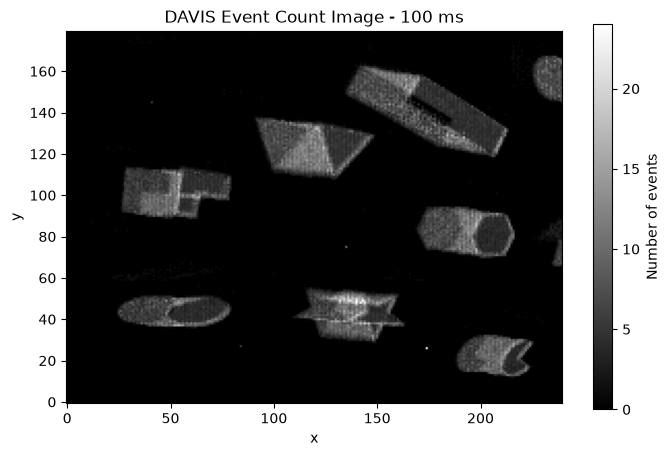

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.imshow(event_frame, cmap="gray", origin="lower")
plt.xlabel("x")
plt.ylabel("y")
plt.title("DAVIS Event Count Image - 100 ms")
plt.colorbar(label="Number of events")
plt.show()

### 2)Polarity Image 

In [50]:
polarity_frame = np.zeros(
    (height, width),
    dtype=np.int32
)

for xi, yi, pi in zip(x_w, y_w, p_w):

    if pi == 1:
        polarity_frame[yi, xi] += 1
    else:
        polarity_frame[yi, xi] -= 1

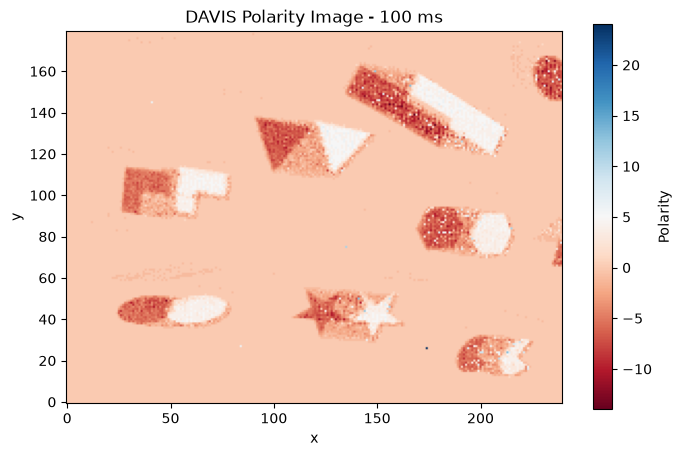

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.imshow(polarity_frame, cmap="RdBu", origin="lower"  )
plt.xlabel("x")
plt.ylabel("y")
plt.title("DAVIS Polarity Image - 100 ms")
plt.colorbar(label="Polarity")
plt.show()

### 3)Surface of Active Event (SAE)

In [ ]:
import numpy as np
sae = np.zeros(
    (height, width),
    dtype=np.int64
)
#1 sae
for xi, yi, ti in zip(x_w, y_w, t_w):
    sae[yi, xi] = ti

sae_recency = np.zeros(
    (height, width),
    dtype=np.int64
)

valid = sae > 0
#2 sae_recency
sae_recency[valid] = t_end - sae[valid]

sae_vis = np.zeros(
    (height, width),
    dtype=np.float32
)

valid = sae > 0
#3 sae_vis
sae_vis[valid] = (
    sae[valid] - t_start
) / (t_end - t_start)

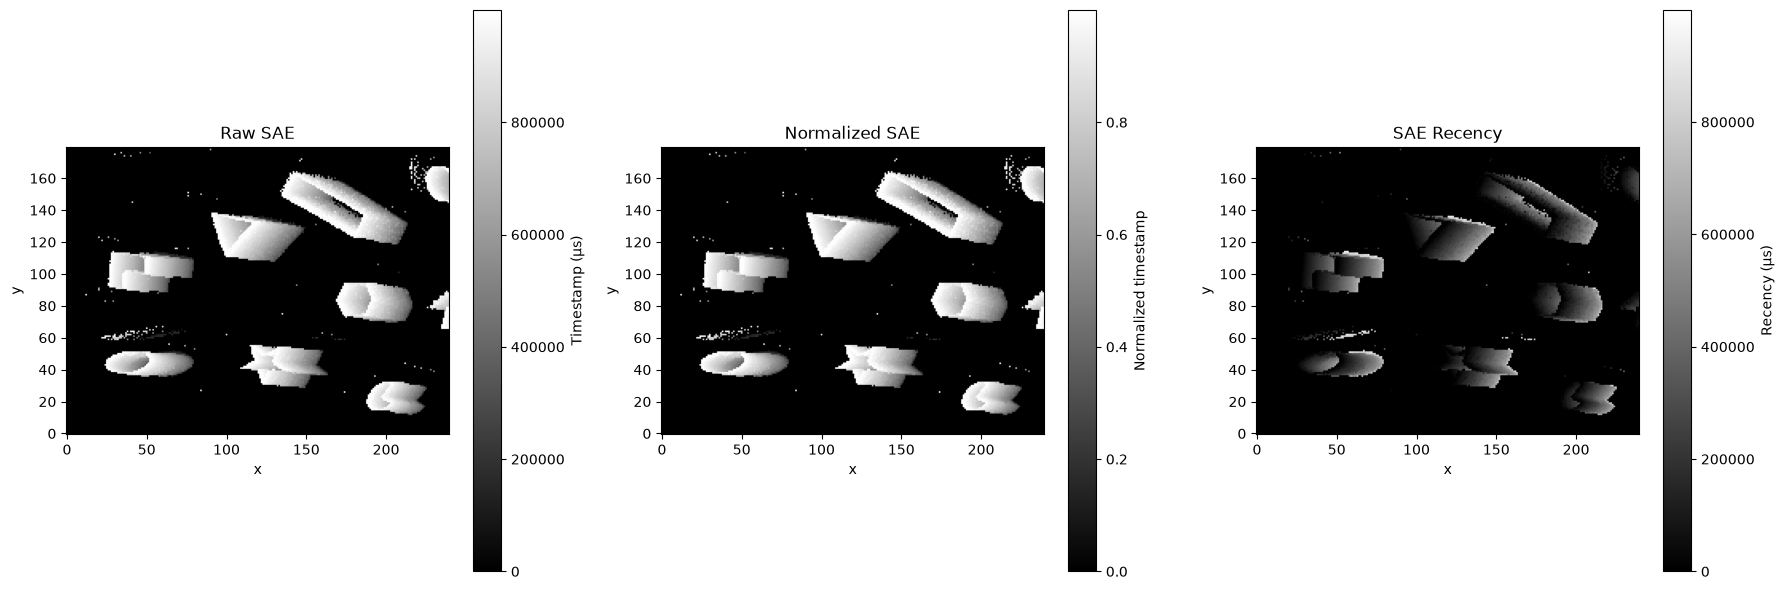

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Raw SAE
im1 = axes[0].imshow(
    sae,
    cmap="gray",
    origin="lower"
)
axes[0].set_title("Raw SAE")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
fig.colorbar(im1, ax=axes[0], label="Timestamp (μs)")

# 2. Normalized SAE
im2 = axes[1].imshow(
    sae_vis,
    cmap="gray",
    origin="lower"
)
axes[1].set_title("Normalized SAE")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
fig.colorbar(im2, ax=axes[1], label="Normalized timestamp")

# 3. SAE Recency
im3 = axes[2].imshow(
    sae_recency,
    cmap="gray",
    origin="lower"
)
axes[2].set_title("SAE Recency")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
fig.colorbar(im3, ax=axes[2], label="Recency (μs)")

plt.tight_layout()
plt.show()

### 4) Time Surface representation

In [63]:
import numpy as np
import matplotlib.pyplot as plt

t_current = t_end
tau = 200000       # 200 μs

time_surface = np.zeros(
    (height, width),
    dtype=np.int64
)

for xi, yi, ti in zip(x_w, y_w, t_w):
    time_surface[yi, xi] = ti

# Exponential time surface
ts_exp = np.zeros(
    (height, width),
    dtype=np.float32
)

valid = time_surface > 0

ts_exp[valid] = np.exp(
    -(t_current - time_surface[valid]) / tau
)

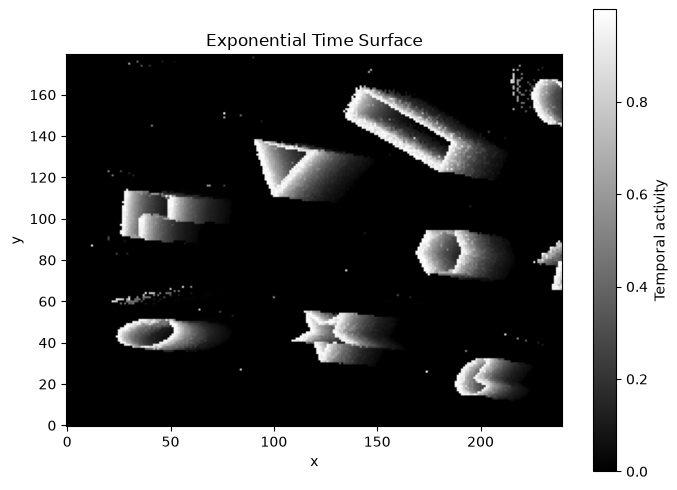

In [64]:
plt.figure(figsize=(8, 6))

plt.imshow(
    ts_exp,
    cmap="gray",
    origin="lower"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Exponential Time Surface")
plt.colorbar(label="Temporal activity")

plt.show()

### 5)Voxel Grid Representation